# Compare models

#Import libraries

In [1]:
import psycopg2
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import numpy as np

#Database connection details

In [3]:
username = 'postgres'
password = 'Hypatia03'
host = 'localhost'  
port = '5432'       # default PostgreSQL port
database = 'newdatabase'

#Create the SQLAlchemy engine

In [5]:
engine = create_engine(f'postgresql://{username}:{password}@{host}:{port}/{database}')

#Use the engine to read the SQL query

In [10]:
df = pd.read_sql_query("SELECT * FROM newtable", engine)

In [14]:
print(df.head())

        timestamp_EST  hourly_consumption_education_kwh  \
0 2018-01-01 01:00:00                     557703.755874   
1 2018-01-01 02:00:00                     742646.775589   
2 2018-01-01 03:00:00                     775994.461315   
3 2018-01-01 04:00:00                     678935.956930   
4 2018-01-01 05:00:00                     913626.114568   

   hourly_consumption_food_service_kwh  hourly_consumption_healthcare_kwh  \
0                        217934.270969                      359008.617258   
1                        188827.512749                      396181.354454   
2                        181070.030659                      404640.122622   
3                        193238.731119                      404736.935982   
4                        220071.645454                      440438.974437   

   hourly_consumption_lodging_kwh  hourly_consumption_mercantile_kwh  \
0                   272692.904257                      585816.750435   
1                   278456.402695     

#Convert timestamp to datetime

In [17]:
df['timestamp_EST'] = pd.to_datetime(df['timestamp_EST'])

#Extract month, day, and hour

In [20]:
df['month'] = df['timestamp_EST'].dt.month
df['day'] = df['timestamp_EST'].dt.day
df['hour'] = df['timestamp_EST'].dt.hour

#Define features and target columns

In [25]:
features = ['temp_TX', 'humidity_TX', 'month', 'day', 'hour']
target_columns = [
    'hourly_consumption_education_kwh',                
    'hourly_consumption_food_service_kwh',             
    'hourly_consumption_healthcare_kwh',               
    'hourly_consumption_lodging_kwh',                  
    'hourly_consumption_mercantile_kwh',               
    'hourly_consumption_mobile_home_kwh',              
    'hourly_consumption_multi_fam_2_4_kwh',            
    'hourly_consumption_multi_fam_5plus_kwh',          
    'hourly_consumption_office_kwh',                   
    'hourly_consumption_single_fam_attached_kwh',      
    'hourly_consumption_single_fam_detached_kwh',      
    'hourly_consumption_warehouse_and_storage_kwh'
]                        

#Function to build and save models

In [28]:
def build_and_save_models(df, features, target):
    # Split the data
    X = df[features]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Define models
    models = {
        'LinearRegression': LinearRegression(),
        'DecisionTreeRegressor': DecisionTreeRegressor(),
        'RandomForestRegressor': RandomForestRegressor(),
        'SVR': SVR()
    }

    # Train and save each model
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        with open(f'C:/00 Grand Canyon University/Capstone/djangomodel/{target}_{model_name}.pkl', "wb") as model_file:
            pickle.dump(model, model_file)
        print(f"Model for {target} using {model_name} saved as {target}_{model_name}.pkl")

#Function to evaluate models

In [31]:
def evaluate_models(df, features, target):
    # Define models
    models = ['LinearRegression', 'DecisionTreeRegressor', 'RandomForestRegressor', 'SVR']
    results = {}

    for model_name in models:
        # Load the model
        with open(f"C:/00 Grand Canyon University/Capstone/djangomodel/{target}_{model_name}.pkl", "rb") as model_file:
            model = pickle.load(model_file)

        # Split the data
        X = df[features]
        y = df[target]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Make predictions
        y_pred = model.predict(X_test)

        # Evaluate the model
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Store results
        results[model_name] = {'MSE': mse, 'R^2': r2}
        print(f"Model for {target} using {model_name}:")
        print(f"Mean Squared Error: {mse}")
        print(f"R^2 Score: {r2}")

        # Plotting
        colors = np.where(y_pred > y_test, 'green', 'red')  # Green for overestimation, red for underestimation
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=y_test, y=y_pred, hue=colors, palette=['red', 'green'], legend=False)
        plt.xlabel("Actual Values")
        plt.ylabel("Predicted Values")
        plt.title(f"Actual vs Predicted for {target} using {model_name}")
        plt.axline((0, 0), slope=1, color='blue', linestyle='--')  
        plt.show()

    return results

#Loop through each target variable to build and save models

In [34]:
for target in target_columns:
    build_and_save_models(df, features, target)

Model for hourly_consumption_education_kwh using LinearRegression saved as hourly_consumption_education_kwh_LinearRegression.pkl
Model for hourly_consumption_education_kwh using DecisionTreeRegressor saved as hourly_consumption_education_kwh_DecisionTreeRegressor.pkl
Model for hourly_consumption_education_kwh using RandomForestRegressor saved as hourly_consumption_education_kwh_RandomForestRegressor.pkl
Model for hourly_consumption_education_kwh using SVR saved as hourly_consumption_education_kwh_SVR.pkl
Model for hourly_consumption_food_service_kwh using LinearRegression saved as hourly_consumption_food_service_kwh_LinearRegression.pkl
Model for hourly_consumption_food_service_kwh using DecisionTreeRegressor saved as hourly_consumption_food_service_kwh_DecisionTreeRegressor.pkl
Model for hourly_consumption_food_service_kwh using RandomForestRegressor saved as hourly_consumption_food_service_kwh_RandomForestRegressor.pkl
Model for hourly_consumption_food_service_kwh using SVR saved as 

#Loop through each target variable to evaluate models

Model for hourly_consumption_education_kwh using LinearRegression:
Mean Squared Error: 100139641613.62999
R^2 Score: 0.09613136865212124


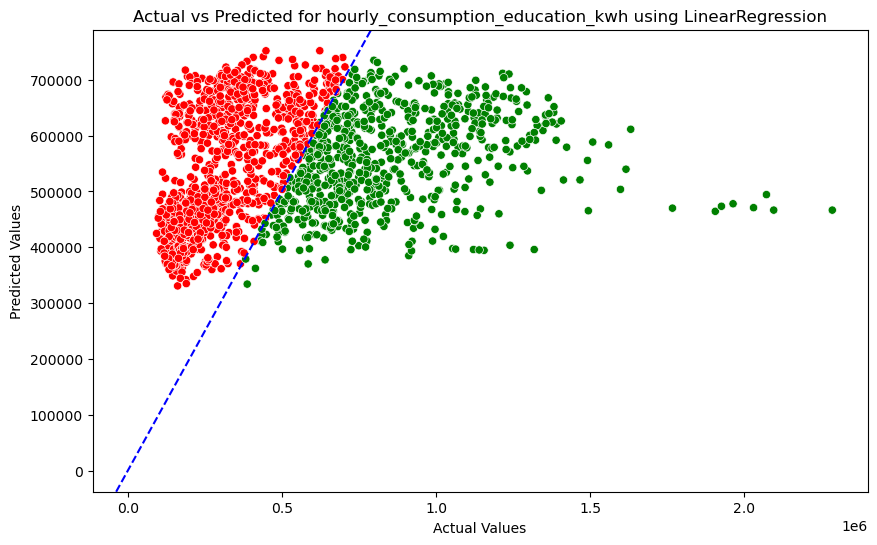

Model for hourly_consumption_education_kwh using DecisionTreeRegressor:
Mean Squared Error: 22880023412.85082
R^2 Score: 0.7934830291566966


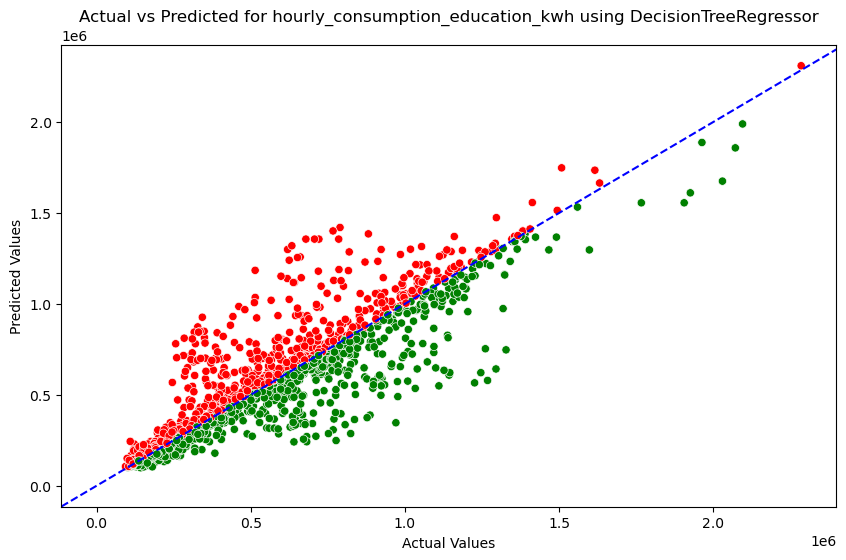

Model for hourly_consumption_education_kwh using RandomForestRegressor:
Mean Squared Error: 12653015309.765533
R^2 Score: 0.885792844410331


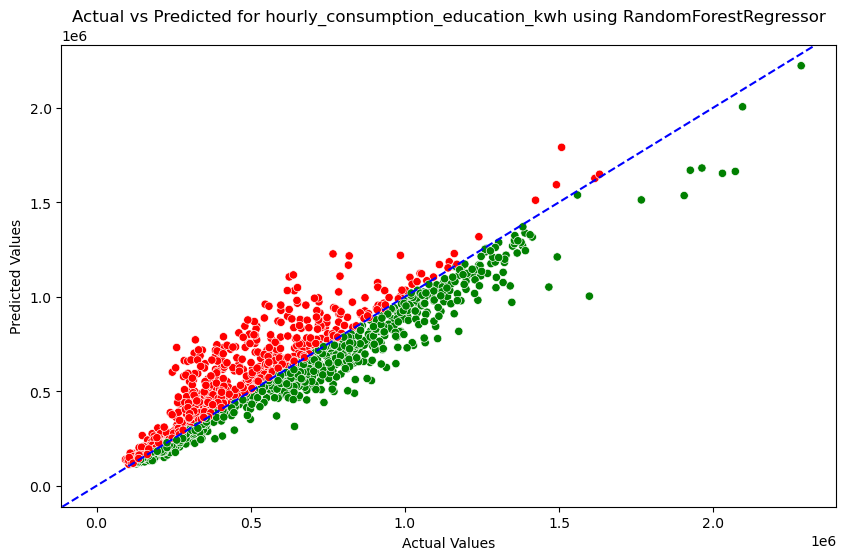

Model for hourly_consumption_education_kwh using SVR:
Mean Squared Error: 112019391149.43262
R^2 Score: -0.011096226540510123


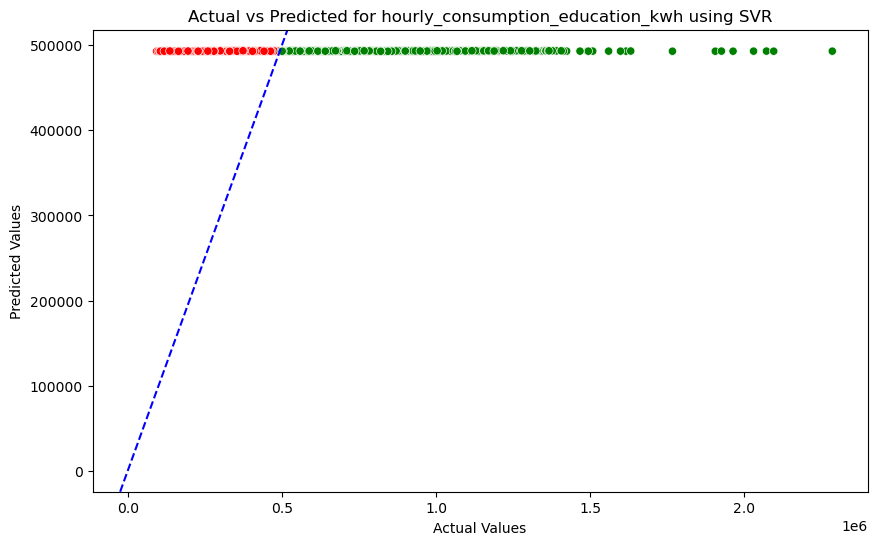

Model for hourly_consumption_food_service_kwh using LinearRegression:
Mean Squared Error: 10191520761.843819
R^2 Score: 0.3862744794208205


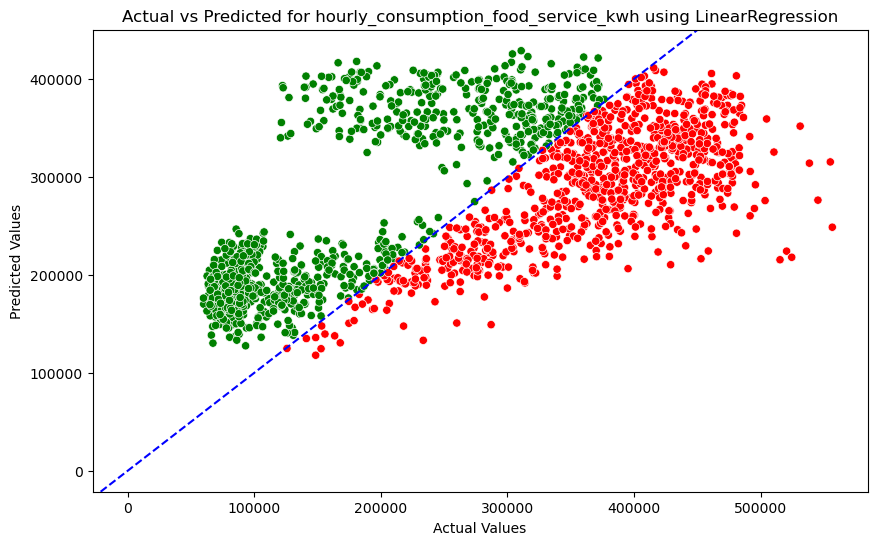

Model for hourly_consumption_food_service_kwh using DecisionTreeRegressor:
Mean Squared Error: 618831437.7485852
R^2 Score: 0.9627344480614783


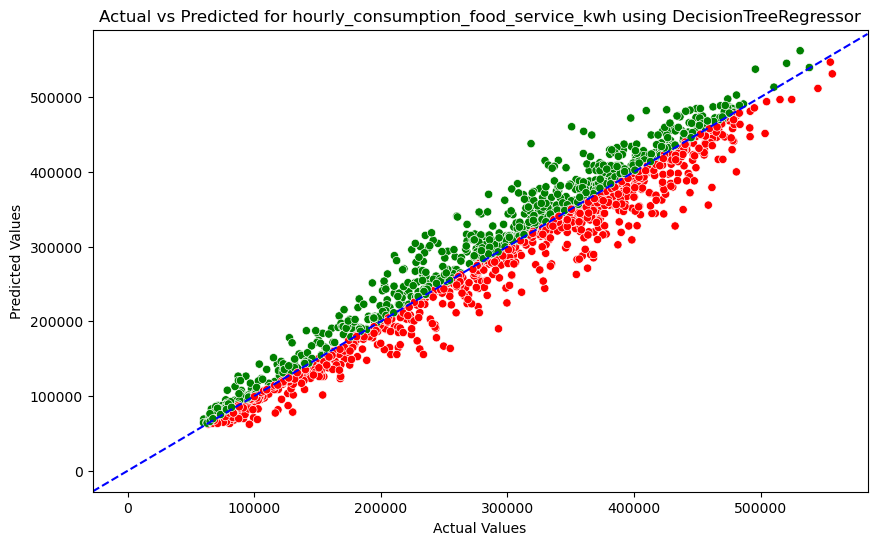

Model for hourly_consumption_food_service_kwh using RandomForestRegressor:
Mean Squared Error: 357934759.9013224
R^2 Score: 0.9784454447979675


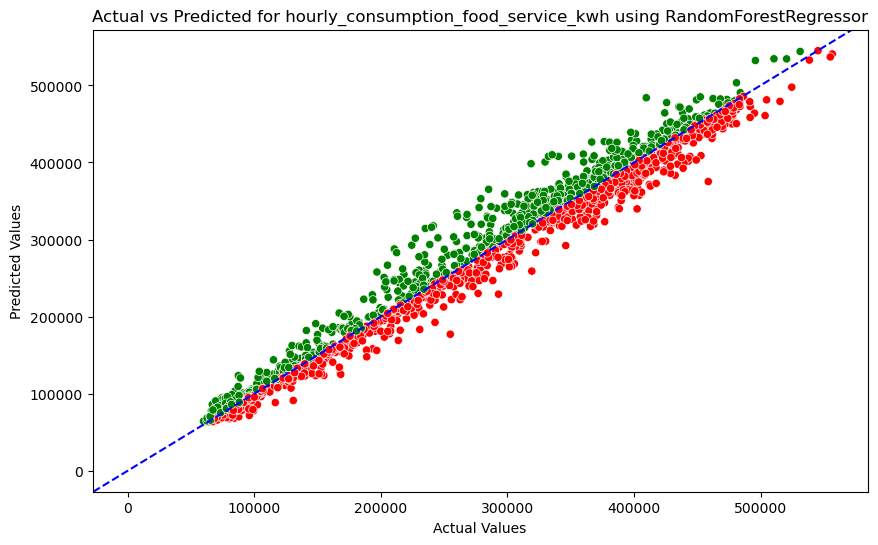

Model for hourly_consumption_food_service_kwh using SVR:
Mean Squared Error: 17347182764.32009
R^2 Score: -0.04463396792299745


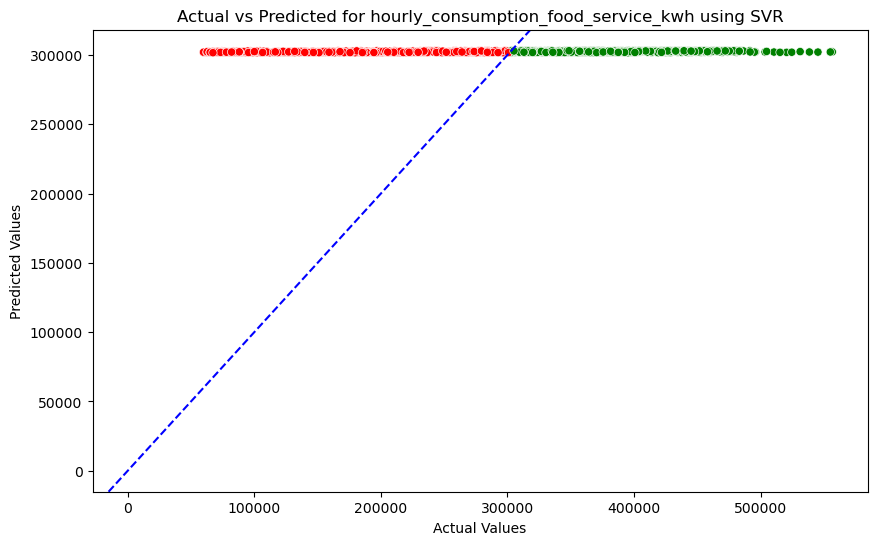

Model for hourly_consumption_healthcare_kwh using LinearRegression:
Mean Squared Error: 8908280725.718306
R^2 Score: 0.13636234758391497


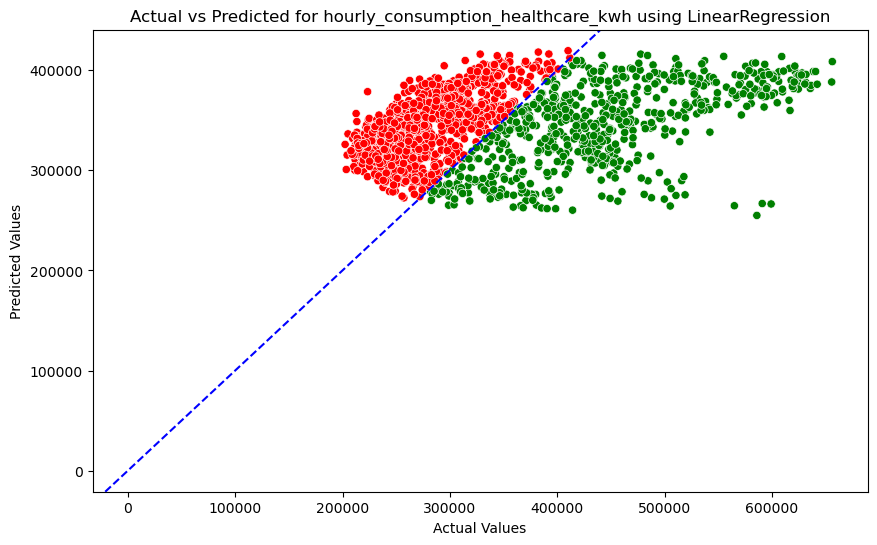

Model for hourly_consumption_healthcare_kwh using DecisionTreeRegressor:
Mean Squared Error: 2869909102.131004
R^2 Score: 0.7217688086033998


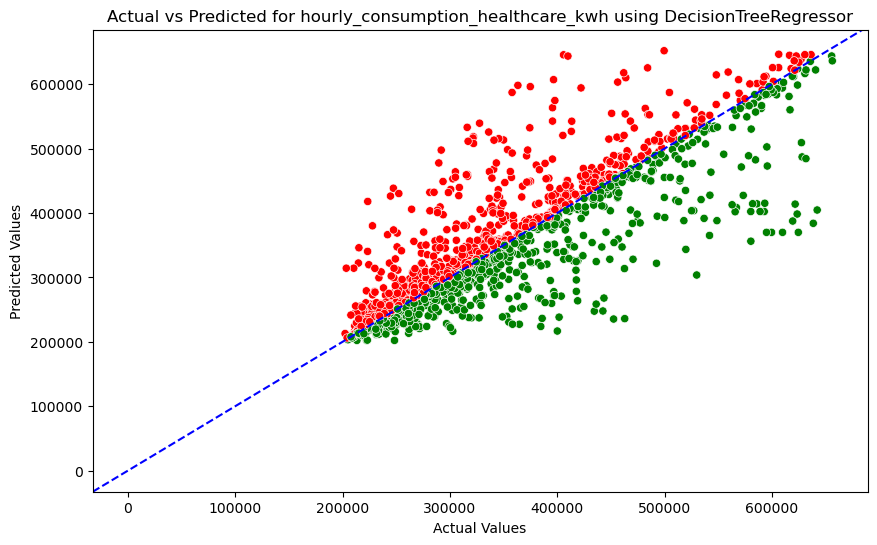

Model for hourly_consumption_healthcare_kwh using RandomForestRegressor:
Mean Squared Error: 1555777906.9052255
R^2 Score: 0.8491708534373676


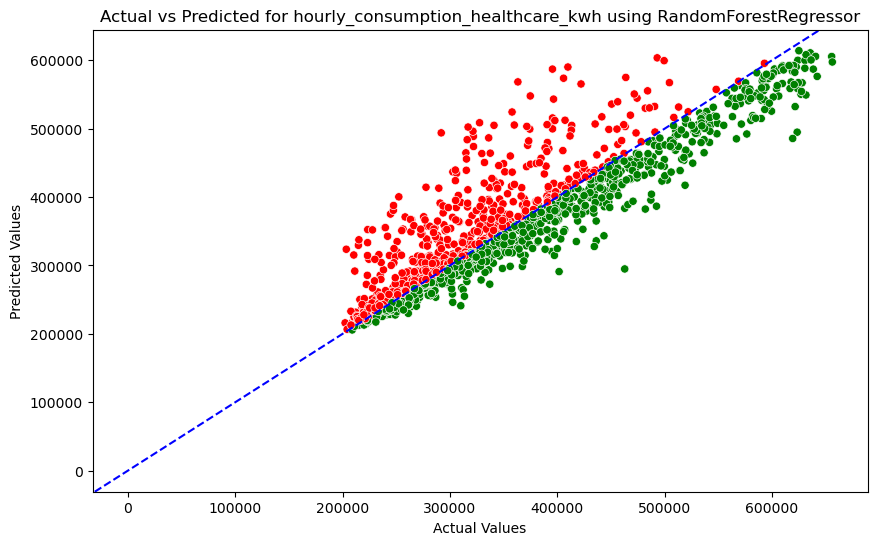

Model for hourly_consumption_healthcare_kwh using SVR:
Mean Squared Error: 11156801275.877142
R^2 Score: -0.08162663021538052


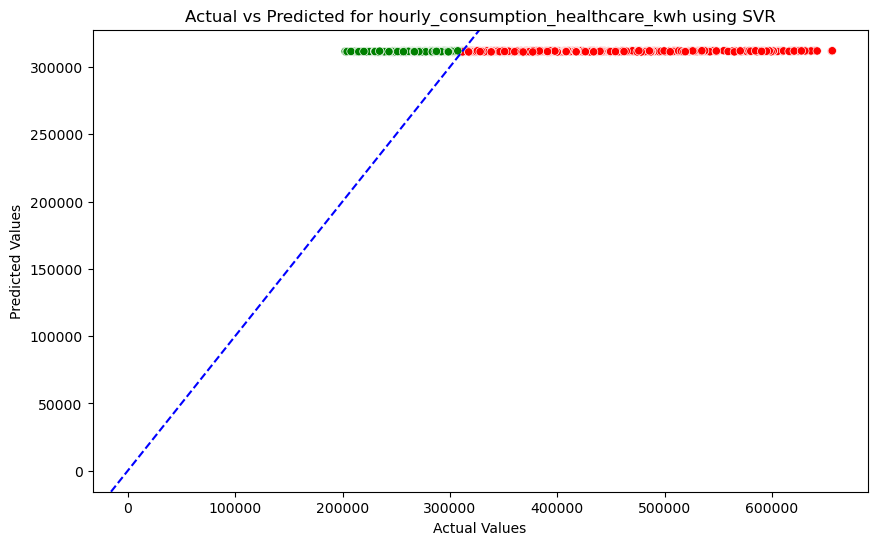

Model for hourly_consumption_lodging_kwh using LinearRegression:
Mean Squared Error: 3378246566.4299774
R^2 Score: 0.33289349703650895


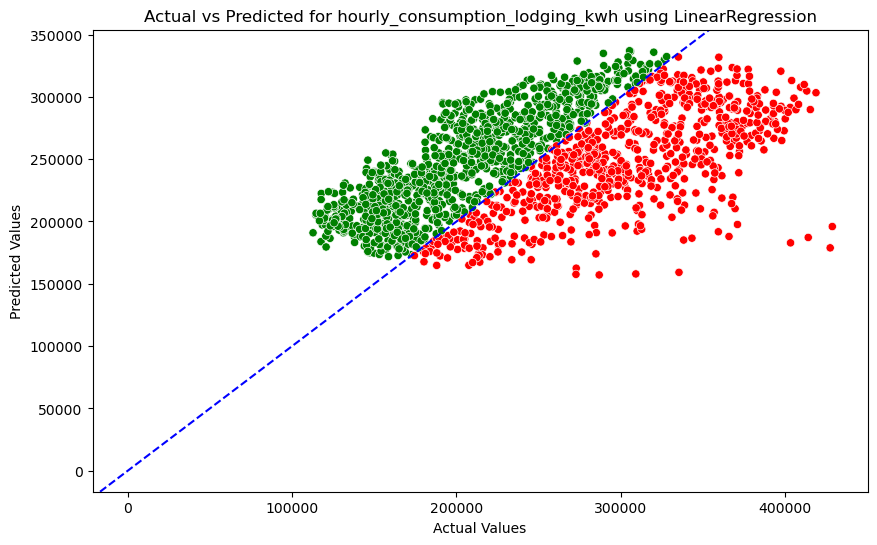

Model for hourly_consumption_lodging_kwh using DecisionTreeRegressor:
Mean Squared Error: 396415394.15328336
R^2 Score: 0.9217193647312859


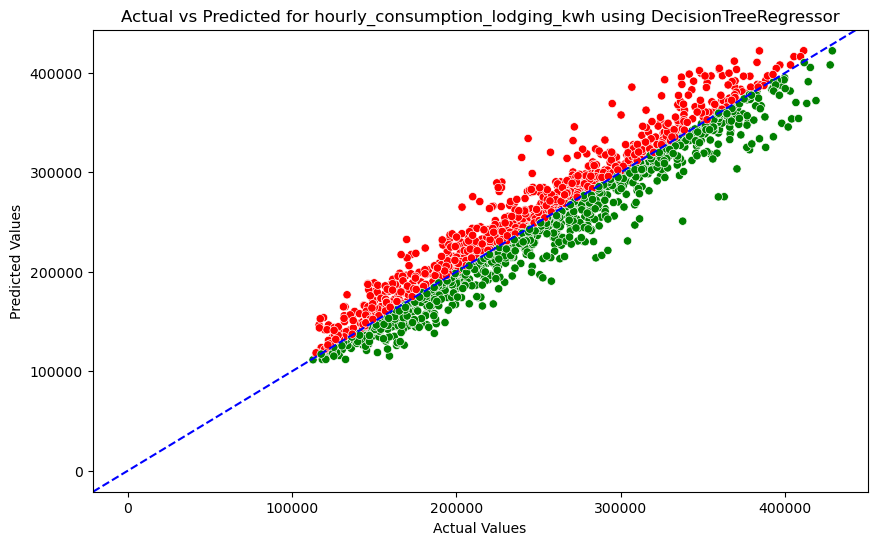

Model for hourly_consumption_lodging_kwh using RandomForestRegressor:
Mean Squared Error: 221553756.39302358
R^2 Score: 0.9562495073288966


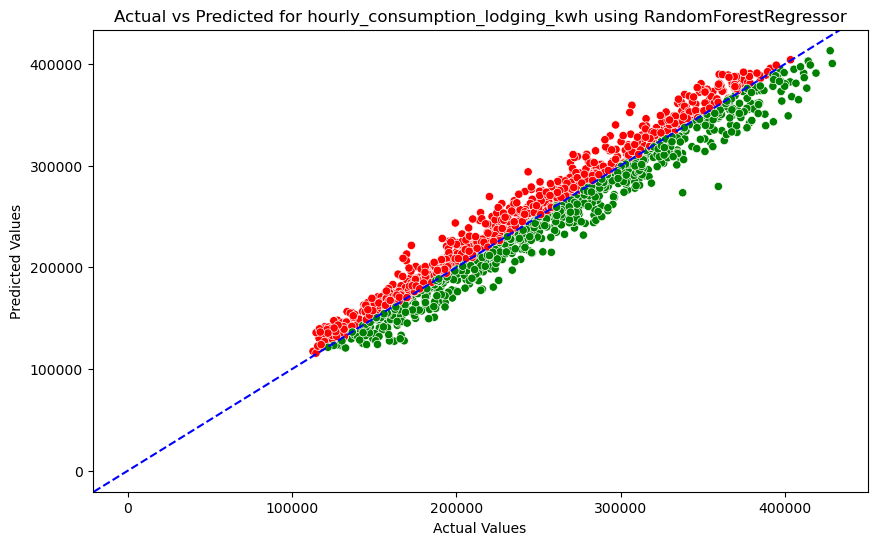

Model for hourly_consumption_lodging_kwh using SVR:
Mean Squared Error: 5035180134.900862
R^2 Score: 0.005696788101930084


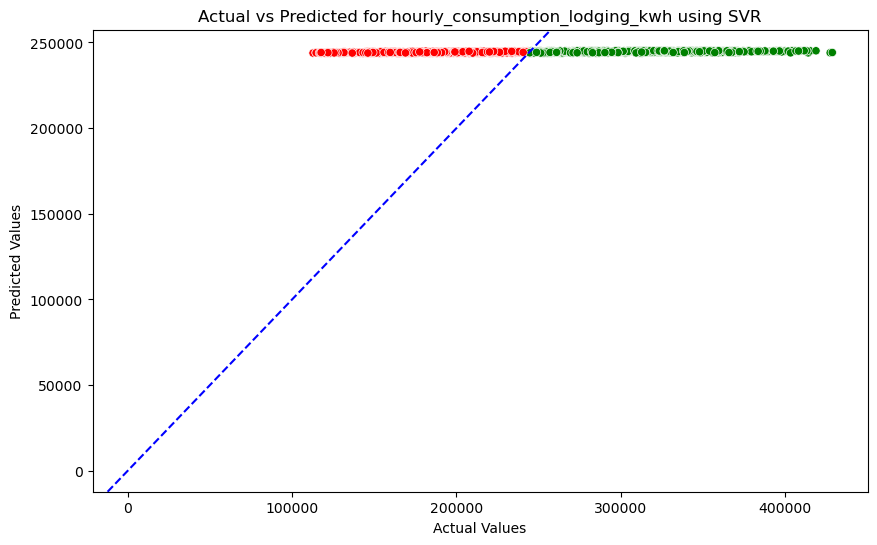

Model for hourly_consumption_mercantile_kwh using LinearRegression:
Mean Squared Error: 64646564405.70734
R^2 Score: 0.35535533886960113


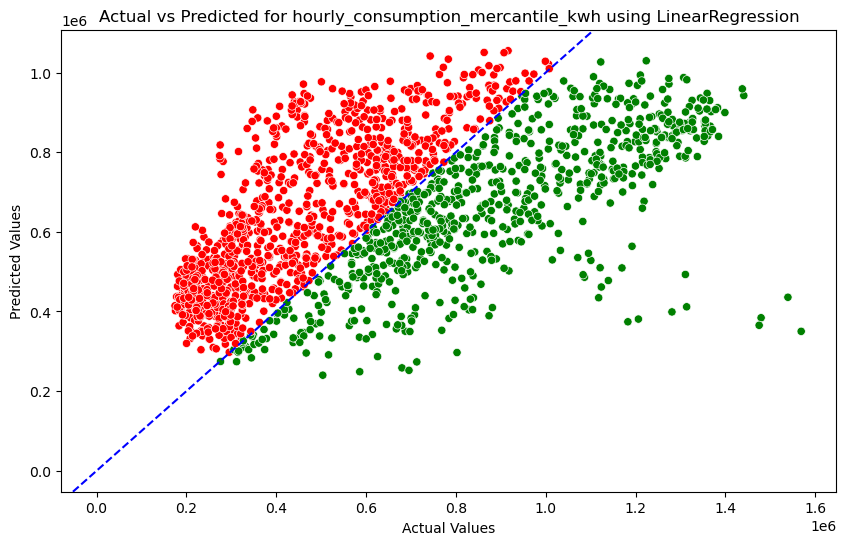

Model for hourly_consumption_mercantile_kwh using DecisionTreeRegressor:
Mean Squared Error: 5304245871.892276
R^2 Score: 0.9471069527967609


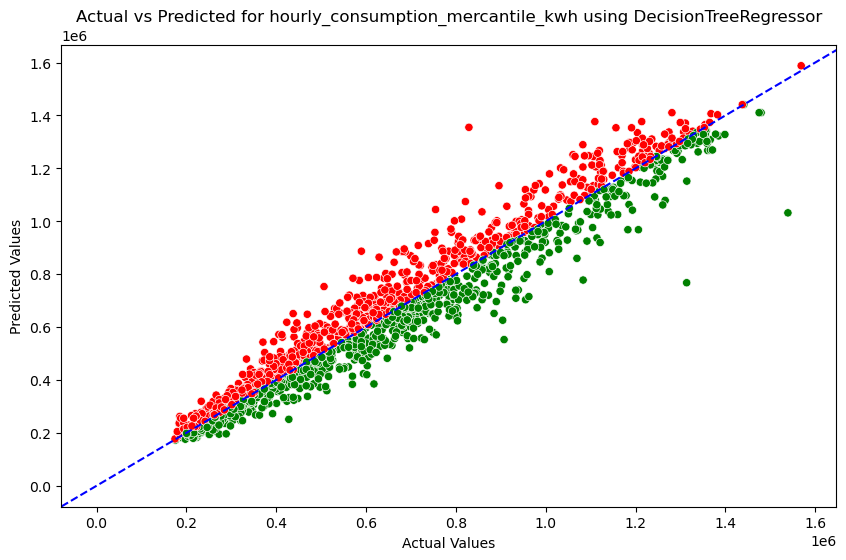

Model for hourly_consumption_mercantile_kwh using RandomForestRegressor:
Mean Squared Error: 2986133226.6024623
R^2 Score: 0.9702227819892711


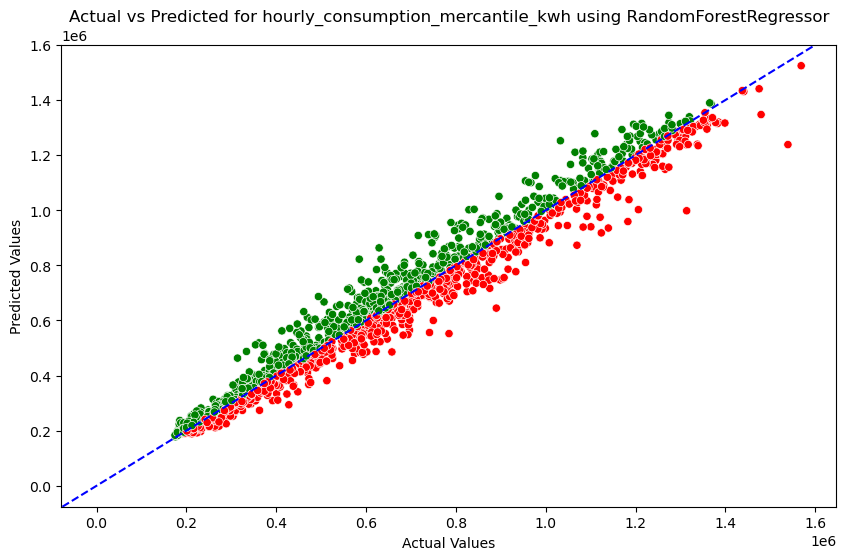

Model for hourly_consumption_mercantile_kwh using SVR:
Mean Squared Error: 100250581737.63692
R^2 Score: 0.0003180696996361032


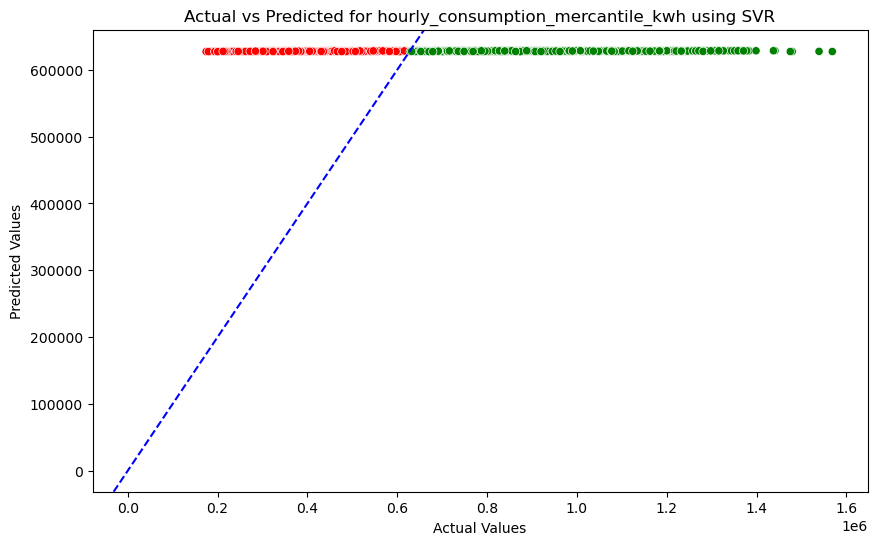

Model for hourly_consumption_mobile_home_kwh using LinearRegression:
Mean Squared Error: 17026998985.406355
R^2 Score: 0.24331178445597879


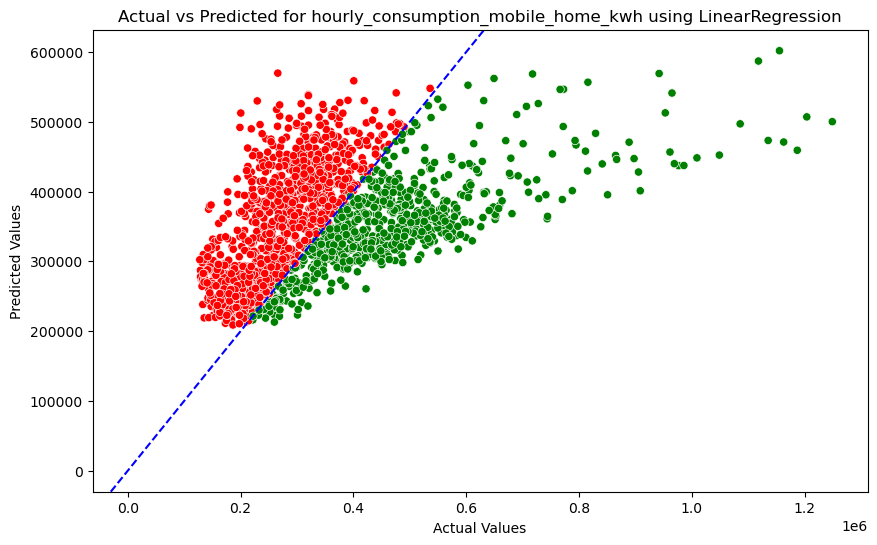

Model for hourly_consumption_mobile_home_kwh using DecisionTreeRegressor:
Mean Squared Error: 2846994000.455224
R^2 Score: 0.8734781853387428


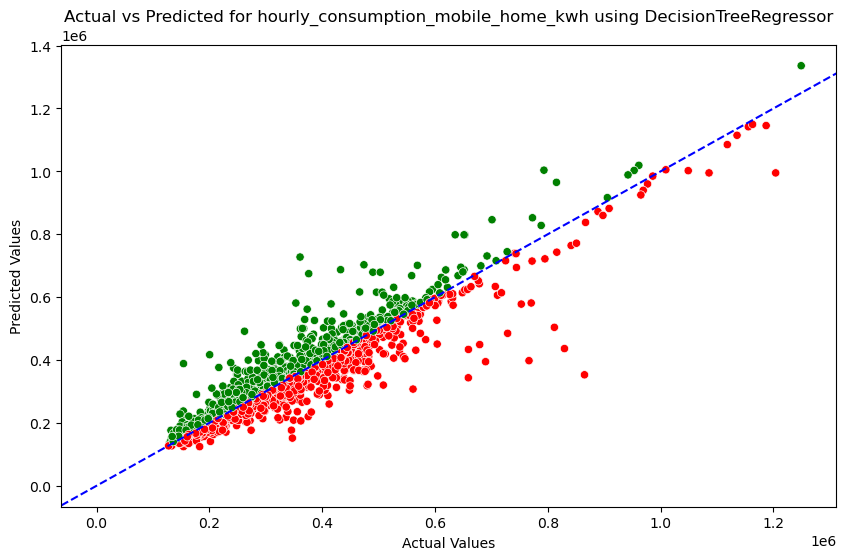

Model for hourly_consumption_mobile_home_kwh using RandomForestRegressor:
Mean Squared Error: 1436290112.9683318
R^2 Score: 0.9361705604424461


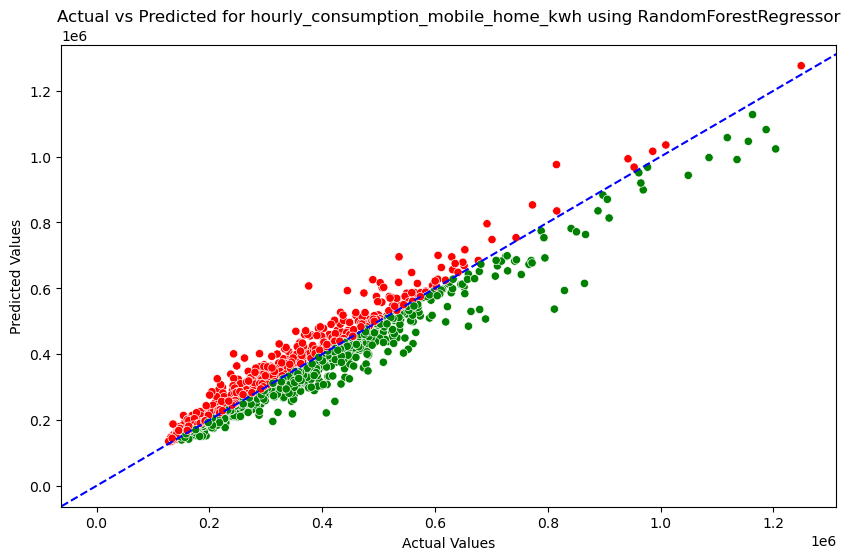

Model for hourly_consumption_mobile_home_kwh using SVR:
Mean Squared Error: 23145216853.57002
R^2 Score: -0.028584828971805587


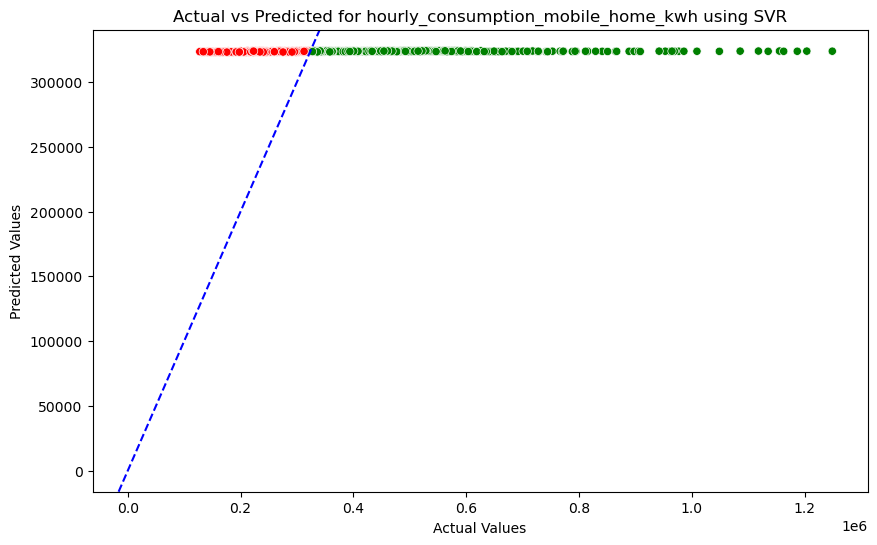

Model for hourly_consumption_multi_fam_2_4_kwh using LinearRegression:
Mean Squared Error: 3448843040.4046474
R^2 Score: 0.2590270884874498


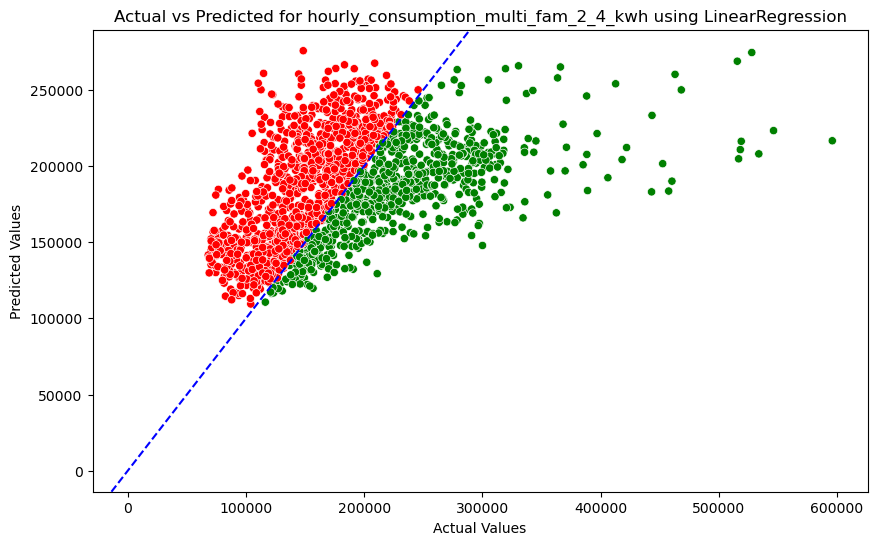

Model for hourly_consumption_multi_fam_2_4_kwh using DecisionTreeRegressor:
Mean Squared Error: 444273964.68656725
R^2 Score: 0.9045491577127831


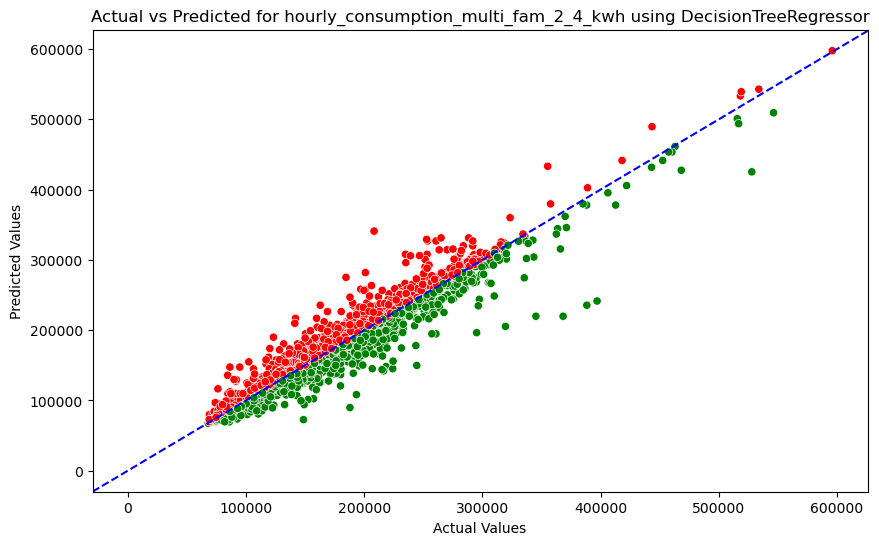

Model for hourly_consumption_multi_fam_2_4_kwh using RandomForestRegressor:
Mean Squared Error: 253722072.54358733
R^2 Score: 0.9454886231106758


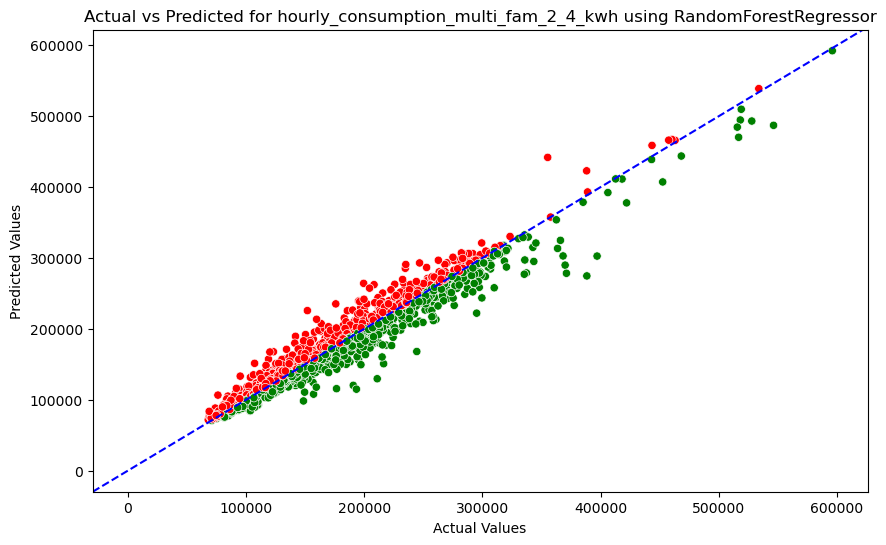

Model for hourly_consumption_multi_fam_2_4_kwh using SVR:
Mean Squared Error: 4744421528.067773
R^2 Score: -0.01932381146656459


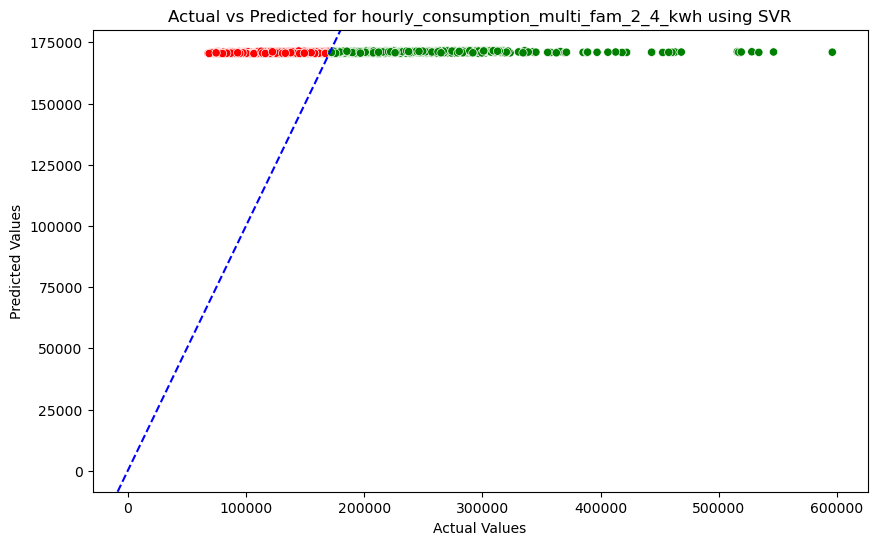

Model for hourly_consumption_multi_fam_5plus_kwh using LinearRegression:
Mean Squared Error: 20363731058.401646
R^2 Score: 0.39898701552997373


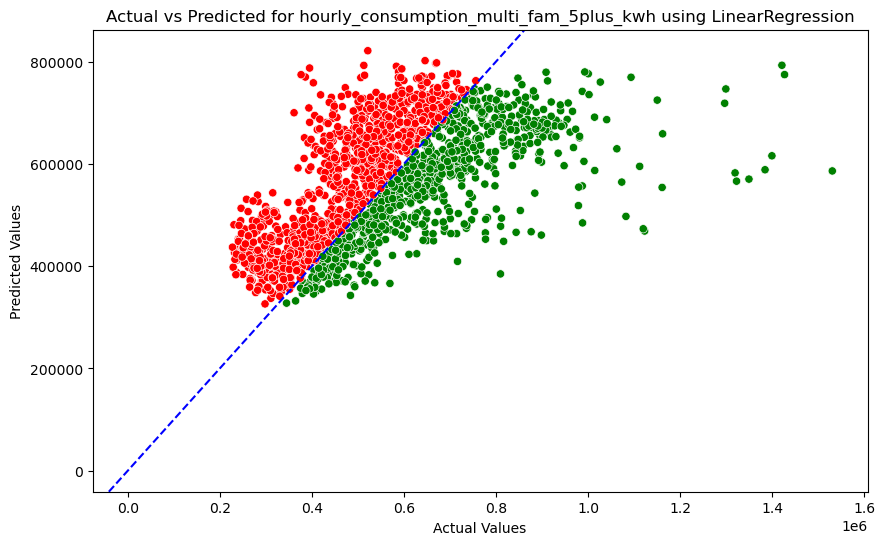

Model for hourly_consumption_multi_fam_5plus_kwh using DecisionTreeRegressor:
Mean Squared Error: 3315357679.1315
R^2 Score: 0.9021508873984884


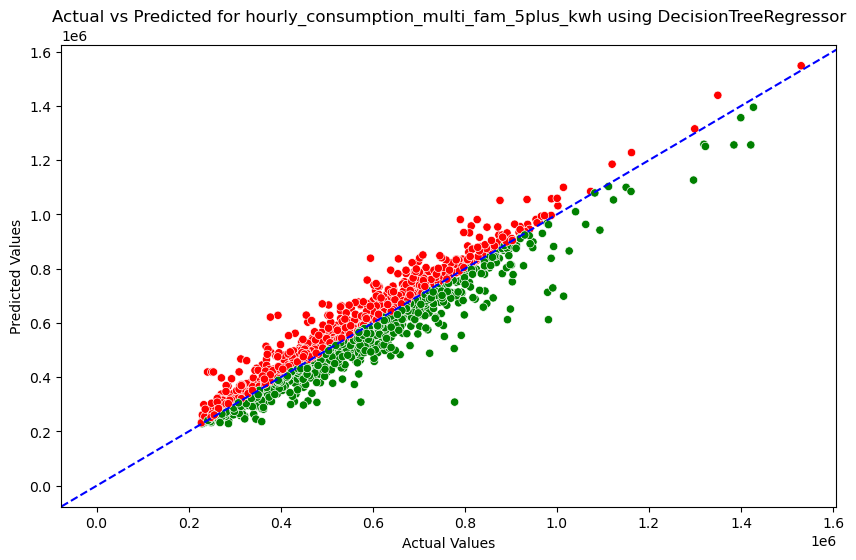

Model for hourly_consumption_multi_fam_5plus_kwh using RandomForestRegressor:
Mean Squared Error: 1797849727.4566793
R^2 Score: 0.9469384550783704


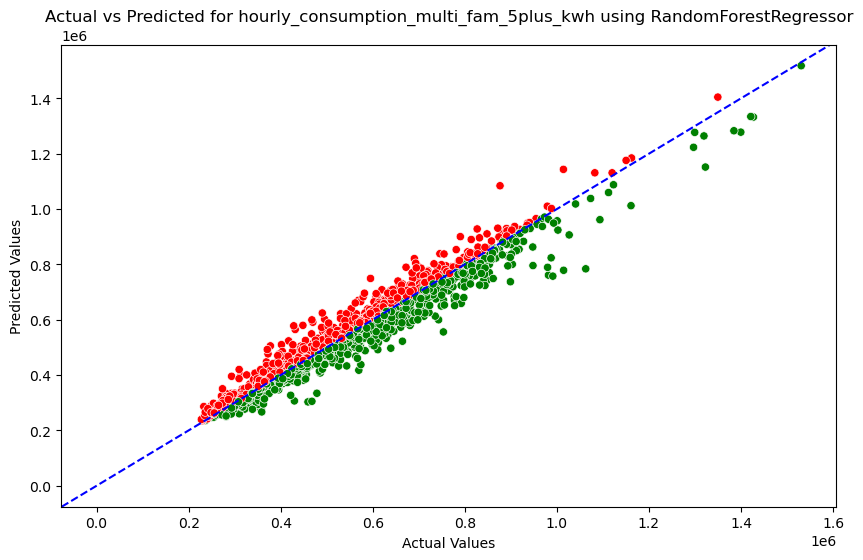

Model for hourly_consumption_multi_fam_5plus_kwh using SVR:
Mean Squared Error: 34156187662.356033
R^2 Score: -0.008082076226465507


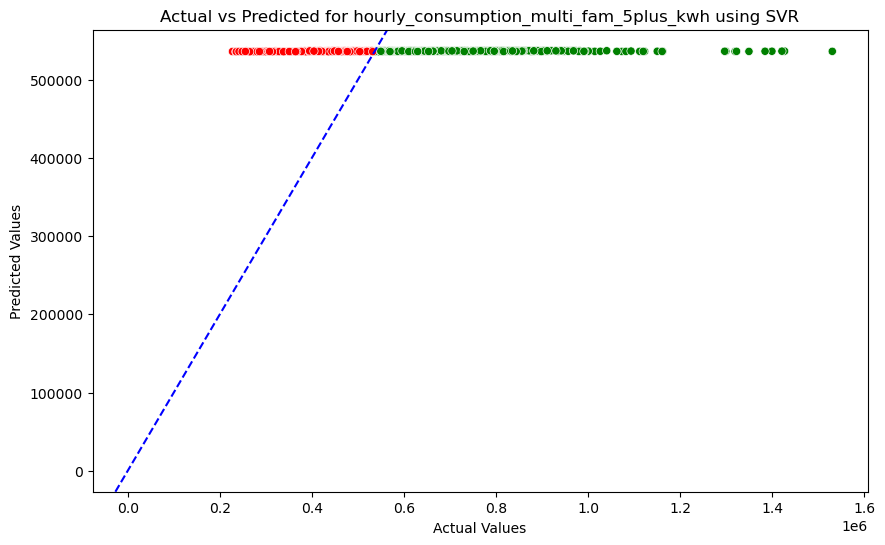

Model for hourly_consumption_office_kwh using LinearRegression:
Mean Squared Error: 30842241185.994934
R^2 Score: 0.12156865734351585


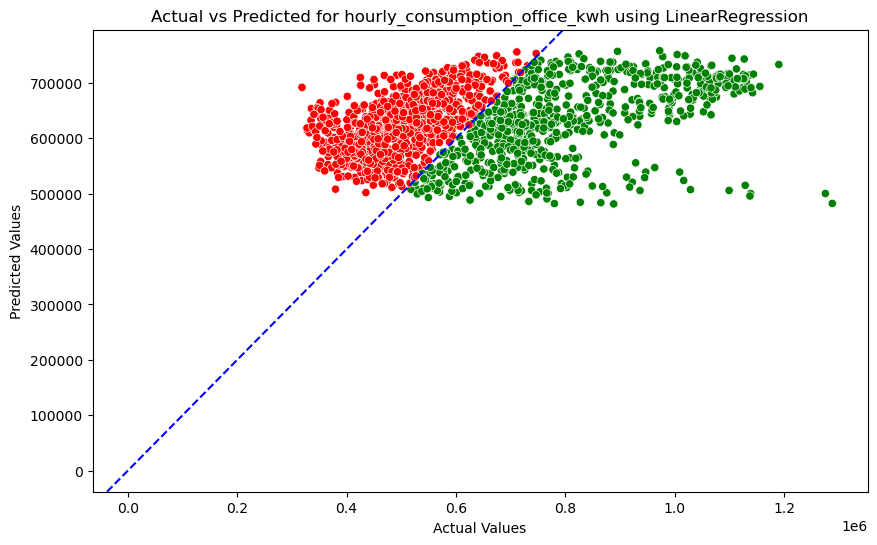

Model for hourly_consumption_office_kwh using DecisionTreeRegressor:
Mean Squared Error: 16181365642.238594
R^2 Score: 0.5391314573604449


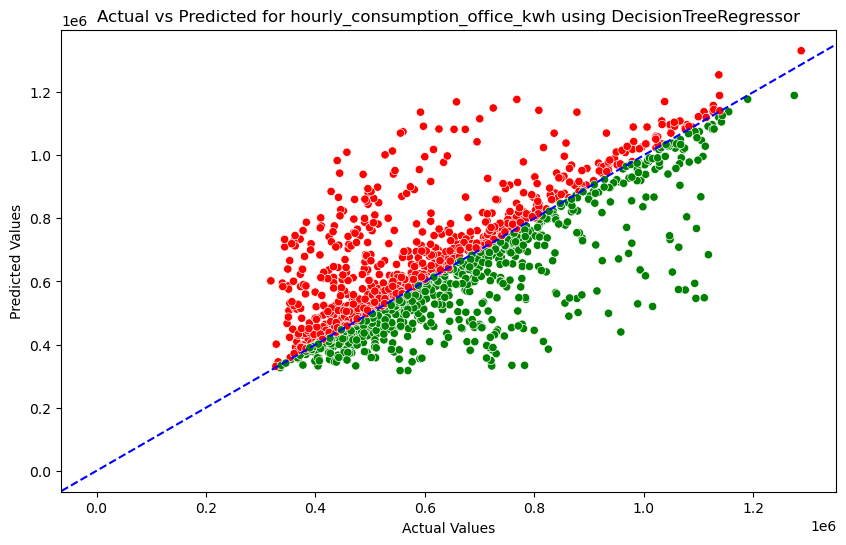

Model for hourly_consumption_office_kwh using RandomForestRegressor:
Mean Squared Error: 8920779802.545675
R^2 Score: 0.7459233739780428


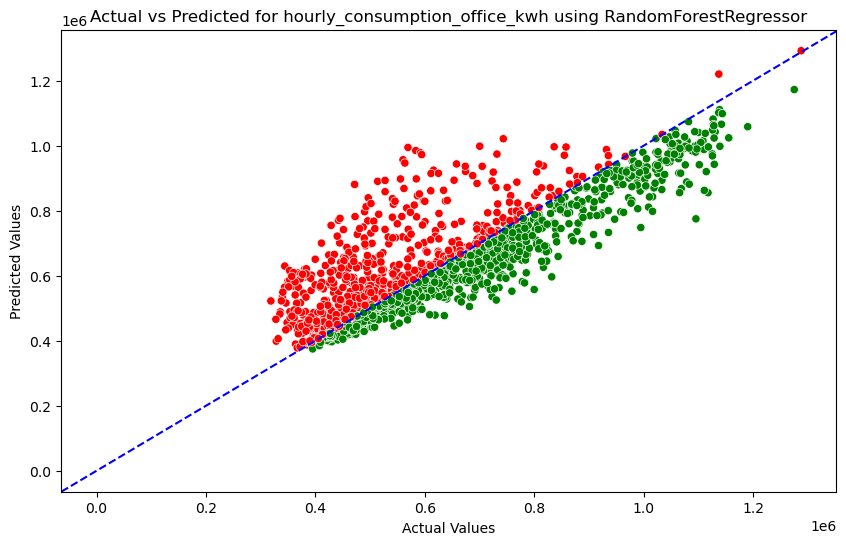

Model for hourly_consumption_office_kwh using SVR:
Mean Squared Error: 36712461523.20875
R^2 Score: -0.0456236521067348


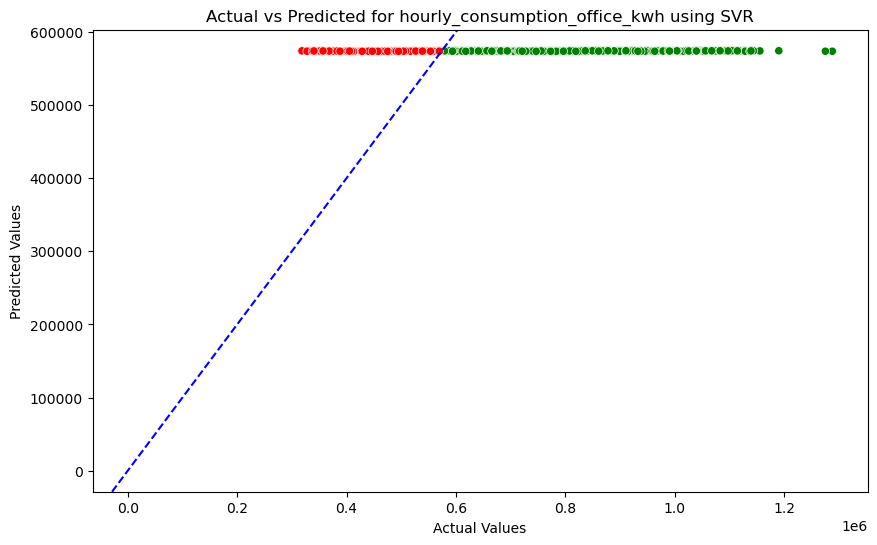

Model for hourly_consumption_single_fam_attached_kwh using LinearRegression:
Mean Squared Error: 2207180021.401993
R^2 Score: 0.21173226623254182


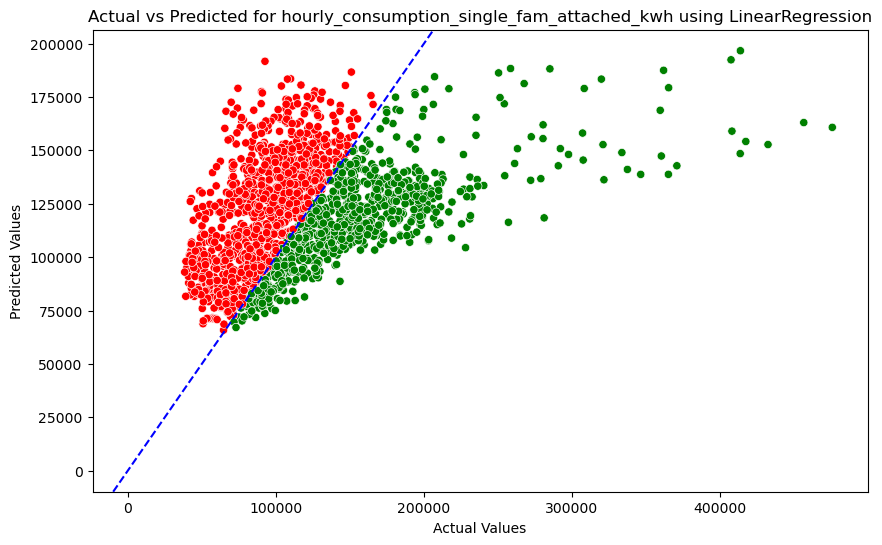

Model for hourly_consumption_single_fam_attached_kwh using DecisionTreeRegressor:
Mean Squared Error: 313744600.0845535
R^2 Score: 0.8879498987430419


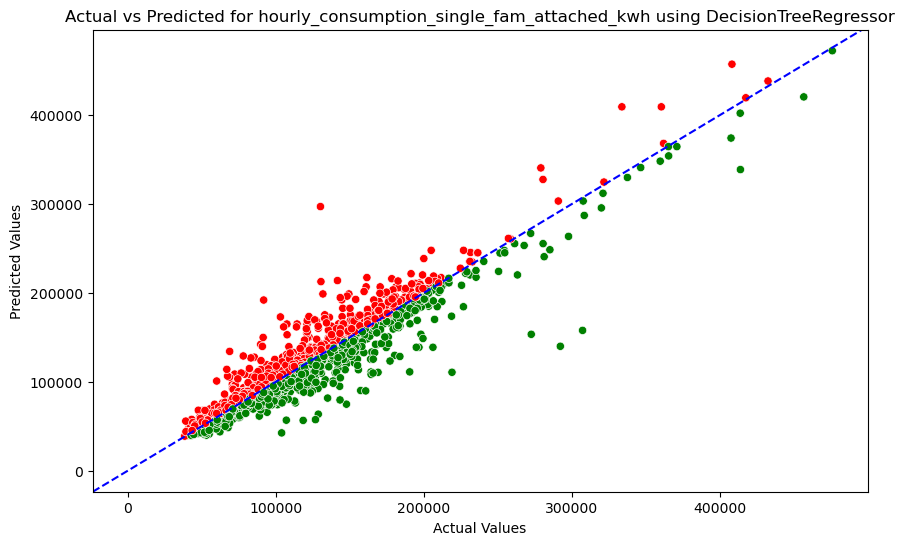

Model for hourly_consumption_single_fam_attached_kwh using RandomForestRegressor:
Mean Squared Error: 160605426.07376066
R^2 Score: 0.9426417084178279


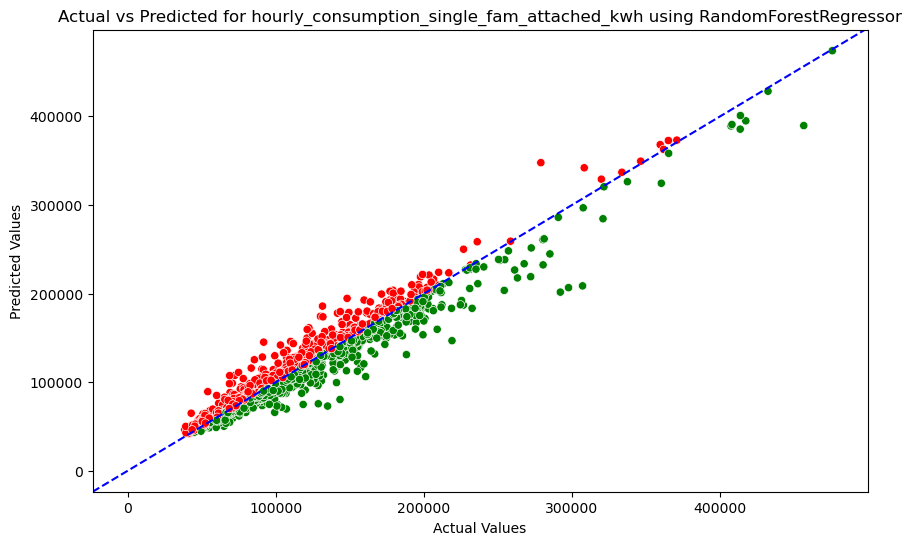

Model for hourly_consumption_single_fam_attached_kwh using SVR:
Mean Squared Error: 2888077293.42958
R^2 Score: -0.031441985230962644


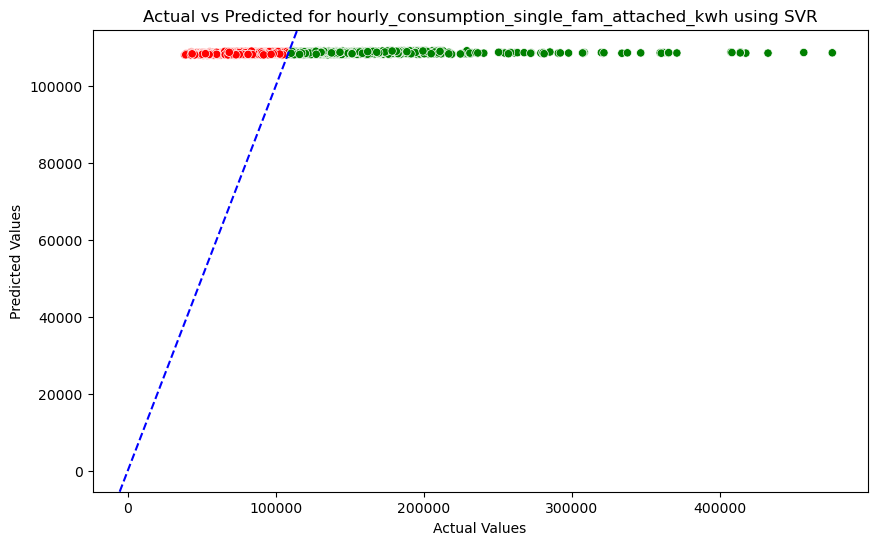

Model for hourly_consumption_single_fam_detached_kwh using LinearRegression:
Mean Squared Error: 5055475650160.516
R^2 Score: 0.1709951658783092


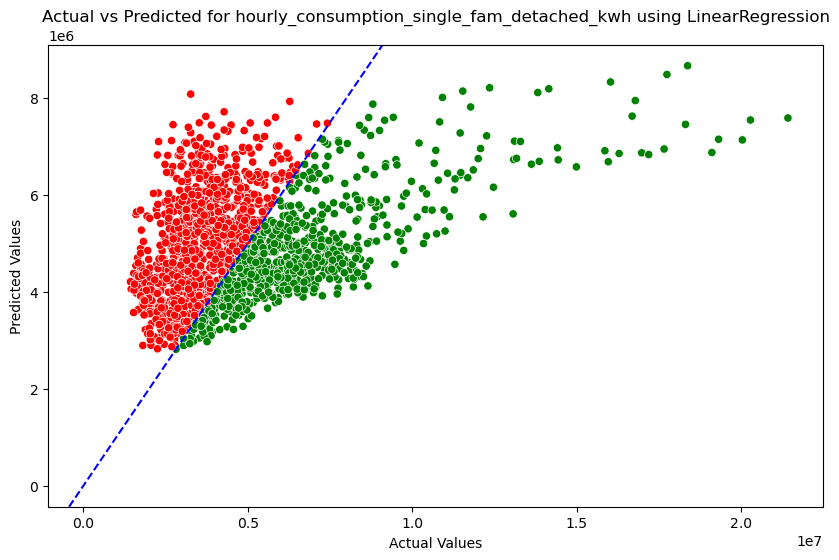

Model for hourly_consumption_single_fam_detached_kwh using DecisionTreeRegressor:
Mean Squared Error: 585573297903.1531
R^2 Score: 0.9039767712700028


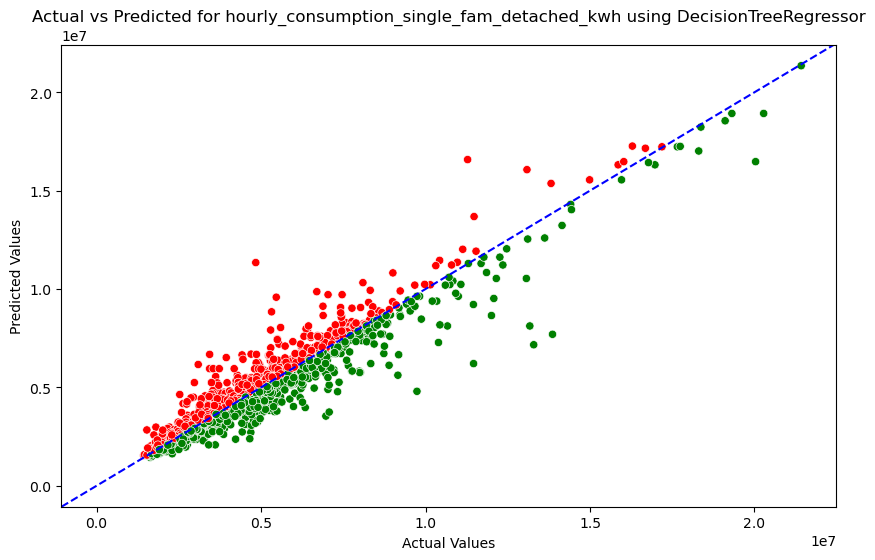

Model for hourly_consumption_single_fam_detached_kwh using RandomForestRegressor:
Mean Squared Error: 312574567406.38214
R^2 Score: 0.9487435317000964


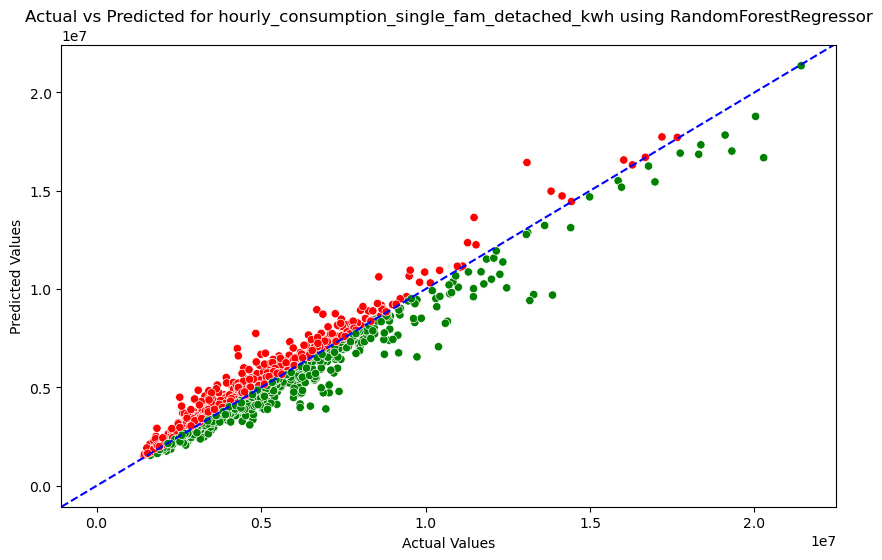

Model for hourly_consumption_single_fam_detached_kwh using SVR:
Mean Squared Error: 6462538141728.934
R^2 Score: -0.05973715055258744


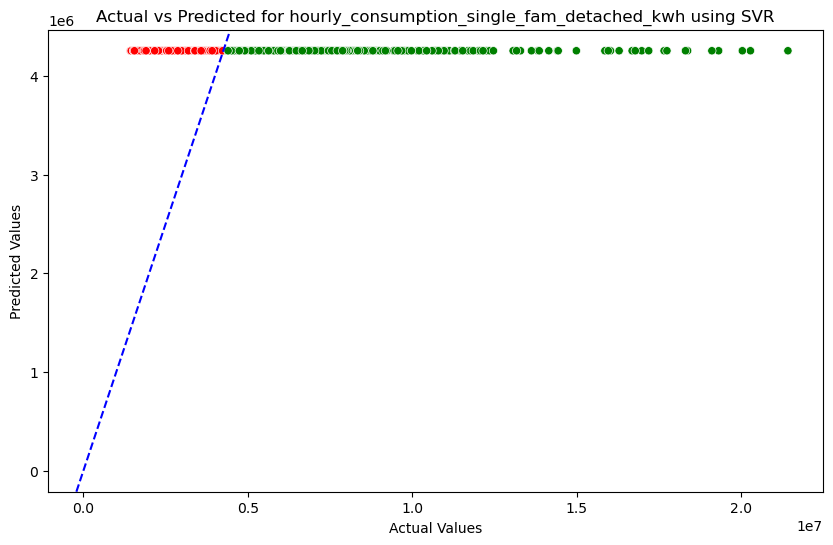

Model for hourly_consumption_warehouse_and_storage_kwh using LinearRegression:
Mean Squared Error: 30979443302.627174
R^2 Score: 0.03780979705170917


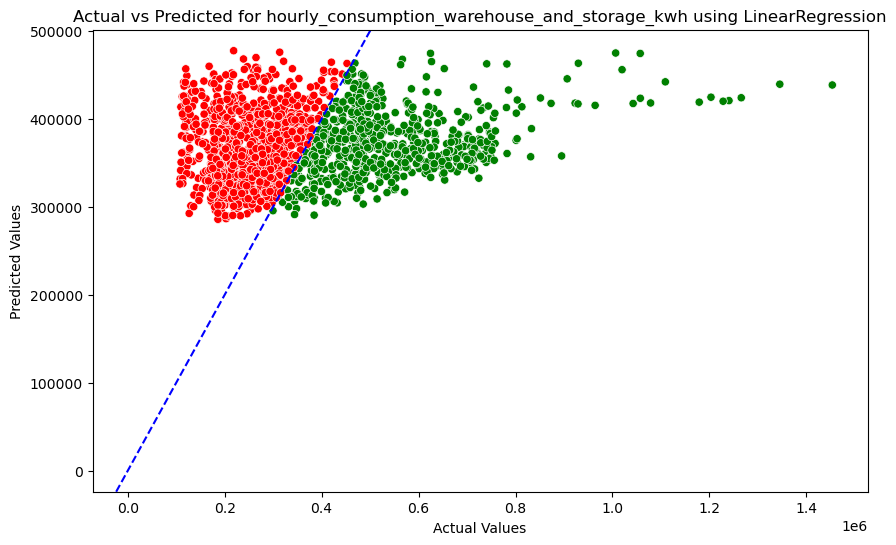

Model for hourly_consumption_warehouse_and_storage_kwh using DecisionTreeRegressor:
Mean Squared Error: 13535521156.750727
R^2 Score: 0.5796003910851295


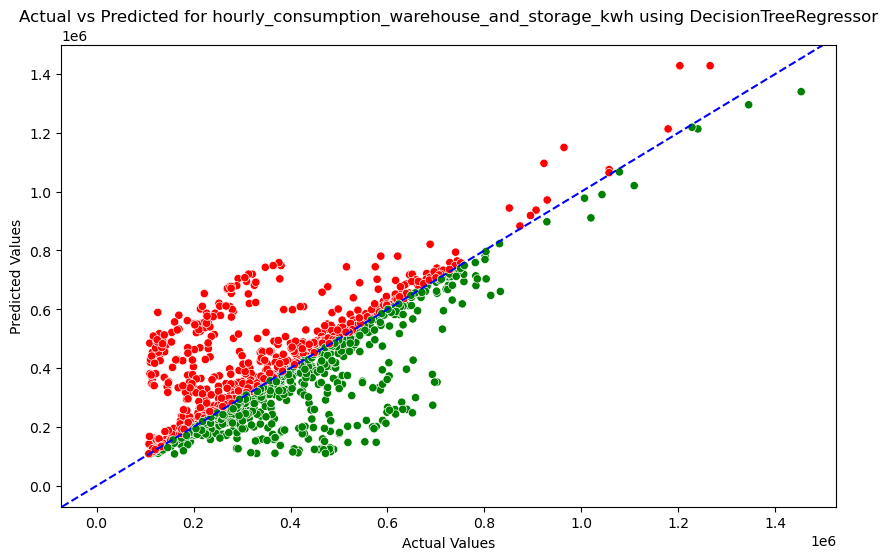

Model for hourly_consumption_warehouse_and_storage_kwh using RandomForestRegressor:
Mean Squared Error: 7563375303.994376
R^2 Score: 0.765089206167004


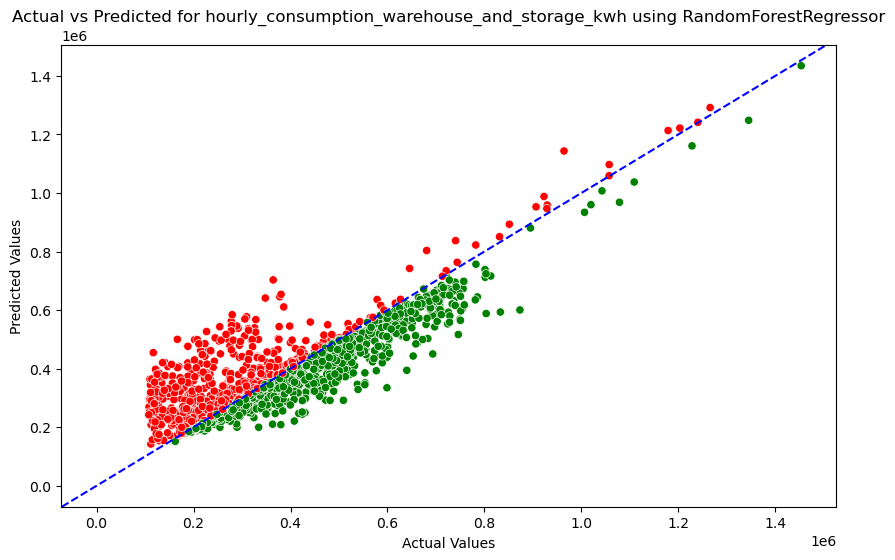

Model for hourly_consumption_warehouse_and_storage_kwh using SVR:
Mean Squared Error: 33712221340.264206
R^2 Score: -0.04706752721007401


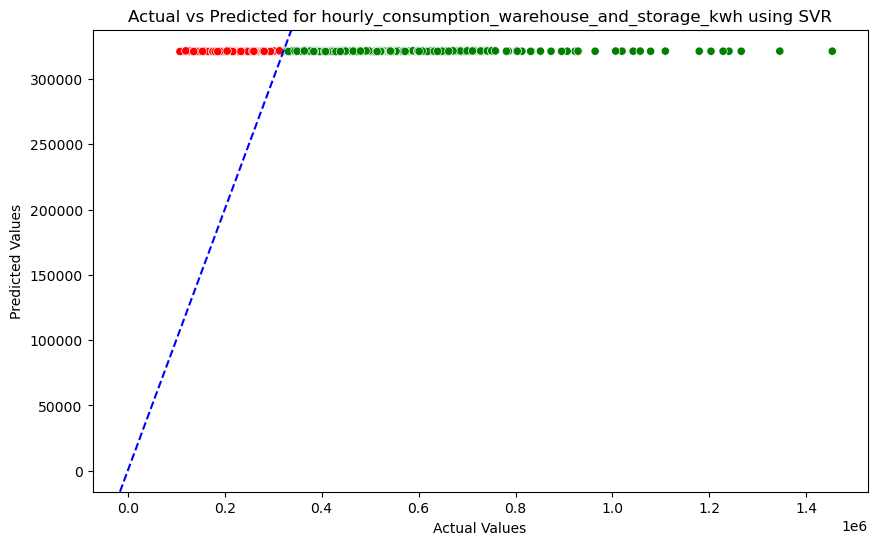

In [37]:
for target in target_columns:
    evaluate_models(df, features, target)